# Propuesta 3: Doble Convolución Cuántica (2 Qubits, Ventana 2x2)

Este notebook presenta la implementación final de la **Propuesta 3**, la cual aplica **dos capas secuenciales** de convolución cuántica basada en Amplitude Encoding con 2 qubits y ventana deslizante de 2x2.

Flujo de dimensiones:
1. **Entrada**: 128x128
2. **Capa 1 (Stride 2)**: 64x64
3. **Capa 2 (Stride 2)**: 32x32 (Salida final hacia el MLP)

Se evalúan tres escenarios de validación:
1. **Escenario 1 (Original)**: Dataset desbalanceado (.mat) con Hold-out simple.
2. **Escenario 2 (Estándar)**: Dataset balanceado (.npz), partición por paciente 70/15/15.
3. **Escenario 3 (5-Fold CV)**: Dataset balanceado (.npz), validación cruzada de 5 pliegues por paciente.

Todos los procesos incluyen medición detallada de tiempos y reportes estadísticos.

In [9]:
import os
import sys
import time
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Importar el Motor Cuántico local
from quantum_utils import QuantumDownsampler

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
print(f"Usando dispositivo: {device}")

# Mapeo de etiquetas
LABEL_MAP = {1: 0, 2: 1, 3: 2} 
CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitario']

Usando dispositivo: mps


In [10]:
class RedNeuronalGeneral(nn.Module):
    """
    Arquitectura MLP para clasificación de tumores.
    Para Propuesta 3, la entrada es (1, 32, 32) tras el doble downsampling.
    """
    def __init__(self, input_shape=(1, 32, 32), num_classes=3):
        super(RedNeuronalGeneral, self).__init__()
        self.input_dim = np.prod(input_shape)
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.3), 
            nn.Linear(256, 128), 
            nn.BatchNorm1d(128), 
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.2), 
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

In [11]:
def _resize_image(image, target_size=128):
    """Redimensiona una imagen 2D al tamaño objetivo manteniendo una salida homogénea."""
    image = np.asarray(image, dtype=np.float32)
    if image.shape[:2] == (target_size, target_size):
        return image

    image_tensor = torch.from_numpy(image).unsqueeze(0).unsqueeze(0)
    resized = torch.nn.functional.interpolate(
        image_tensor,
        size=(target_size, target_size),
        mode='bilinear',
        align_corners=False,
    )
    return resized.squeeze(0).squeeze(0).cpu().numpy()


def load_original_data(dataset_path):
    """Carga el dataset original desbalanceado (.mat)."""
    X, y = [], []
    start_time = time.time()
    files = [f for f in os.listdir(dataset_path) if f.endswith('.mat')]
    print(f"Cargando {len(files)} archivos .mat...")
    
    for filename in tqdm(files):
        filepath = os.path.join(dataset_path, filename)
        with h5py.File(filepath, 'r') as f:
            data = f['cjdata']
            image = np.array(data['image'])
            label = int(data['label'][0,0])
            X.append(_resize_image(image))
            y.append(LABEL_MAP[label])
            
    elapsed = time.time() - start_time
    print(f"Carga completada en {elapsed:.2f}s")
    return np.stack(X, axis=0), np.array(y)


def load_balanced_data_npz(dataset_path):
    """Carga el dataset balanceado agrupado por pacientes (.npz)."""
    X, y, groups = [], [], []
    start_time = time.time()
    
    classes = ['Meningioma', 'Glioma', 'Adenoma_hipofisario']
    for class_name in classes:
        class_dir = os.path.join(dataset_path, class_name)
        files = [f for f in os.listdir(class_dir) if f.endswith('.npz')]
        label = 0 if class_name == 'Meningioma' else (1 if class_name == 'Glioma' else 2)
        
        for filename in tqdm(files, desc=f"Cargando {class_name}"):
            filepath = os.path.join(class_dir, filename)
            patient_id = filename.replace('.npz', '')
            with np.load(filepath) as data:
                imgs = data['imagenes']
                for img in imgs:
                    X.append(_resize_image(img))
                    y.append(label)
                    groups.append(patient_id)
                    
    elapsed = time.time() - start_time
    print(f"Carga completada en {elapsed:.2f}s")
    return np.stack(X, axis=0), np.array(y), np.array(groups)

## Escenario 1: Dataset Original (Desbalanceado)

Cargando 3064 archivos .mat...


100%|██████████| 3064/3064 [00:08<00:00, 345.72it/s]


Carga completada en 8.87s
Aplicando Doble Convolución Cuántica (Escenario 1)...


  0%|          | 0/3064 [00:00<?, ?it/s]

Generando diagrama del circuito cuántico...


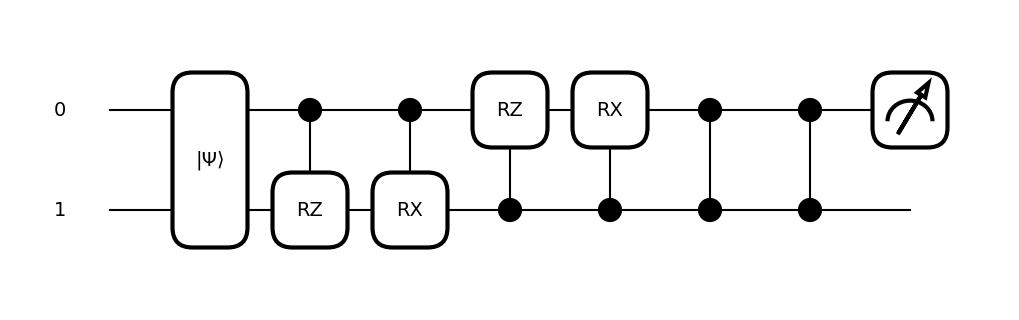

100%|██████████| 3064/3064 [00:13<00:00, 221.50it/s]


Tiempo total de procesamiento cuántico: 13.83s
Tiempo promedio por imagen: 0.0045s

Distribución del Dataset - Train: 80.0%, Test: 20.0%

Iniciando entrenamiento (Escenario 1)...
Entrenamiento completado en 10.23s


In [12]:
MAT_PATH = '../../DataSet/Tumores'

X_orig, y_orig = load_original_data(MAT_PATH)

q_sampler = QuantumDownsampler(n_qubits=2)
X_quantum_orig = []

print("Aplicando Doble Convolución Cuántica (Escenario 1)...")
start_q = time.time()
for img in tqdm(X_orig):
    # n_layers=2 para Propuesta 3
    X_quantum_orig.append(q_sampler.process_image(img, n_layers=2))
time_q = time.time() - start_q

X_quantum_orig = np.array(X_quantum_orig)
print(f"Tiempo total de procesamiento cuántico: {time_q:.2f}s")
print(f"Tiempo promedio por imagen: {time_q/len(X_orig):.4f}s")

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_quantum_orig, y_orig, test_size=0.2, random_state=42)

p_train = (len(X_train)/len(X_orig))*100
p_test = (len(X_test)/len(X_orig))*100
print(f"\nDistribución del Dataset - Train: {p_train:.1f}%, Test: {p_test:.1f}%")

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32).unsqueeze(1), torch.tensor(y_train, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32).unsqueeze(1), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=32)

model = RedNeuronalGeneral(input_shape=(1, 32, 32)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nIniciando entrenamiento (Escenario 1)...")
start_t = time.time()
for epoch in range(50):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        criterion(outputs, labels).backward()
        optimizer.step()
time_t = time.time() - start_t
print(f"Entrenamiento completado en {time_t:.2f}s")

Shape original: (512, 512) | Shape redimensionada: (128, 128)
Generando diagrama del circuito cuántico...


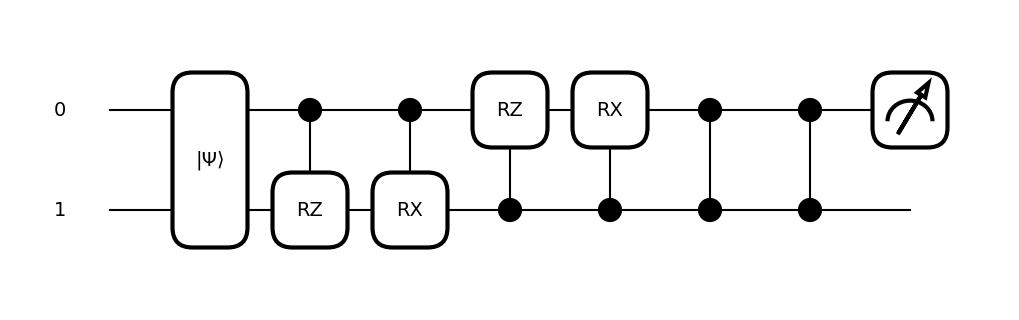

Shape capa 1: (64, 64) | Shape capa 2: (32, 32)


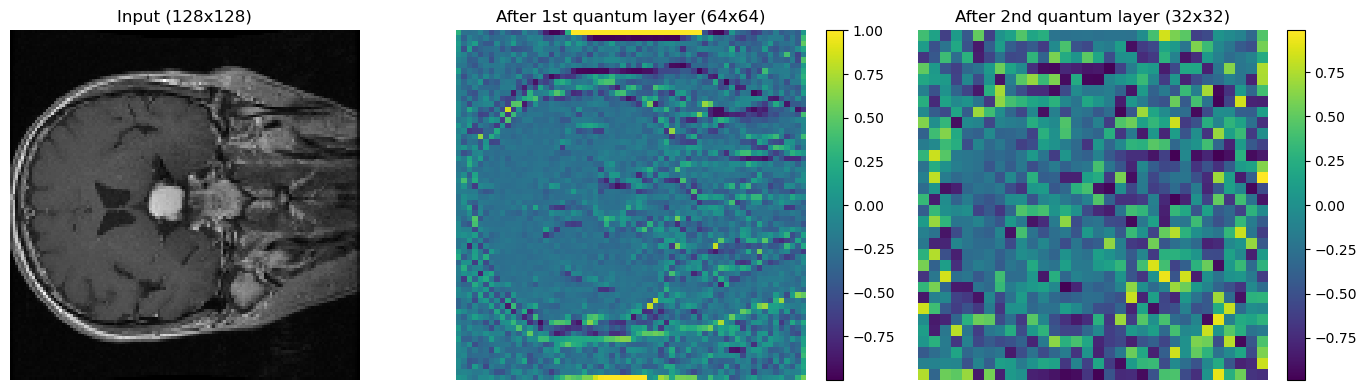

In [17]:
# Visualización: una imagen — entrada, tras 1ª capa cuántica, tras 2ª capa
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

MAT_PATH = '../../DataSet/Tumores'
files = [f for f in os.listdir(MAT_PATH) if f.endswith('.mat')]
if not files:
    raise FileNotFoundError(f'No .mat files found in {MAT_PATH}')

# Cargar la primera imagen disponible
with h5py.File(os.path.join(MAT_PATH, files[0]), 'r') as f:
    img_raw = np.array(f['cjdata']['image'])

# Asegurar tamaño 128x128 usando la función interna
img_resized = _resize_image(img_raw, target_size=128)
print(f'Shape original: {img_raw.shape} | Shape redimensionada: {img_resized.shape}')

# Instanciar sampler (si no existe)
q_sampler = QuantumDownsampler(n_qubits=2)

# Obtener mapas intermedios
map1 = q_sampler.process_image(img_resized, n_layers=1)
map2 = q_sampler.process_image(img_resized, n_layers=2)
print(f'Shape capa 1: {map1.shape} | Shape capa 2: {map2.shape}')

# Mostrar
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_resized, cmap='gray', interpolation='nearest')
plt.title(f'Input ({img_resized.shape[0]}x{img_resized.shape[1]})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(map1, cmap='viridis', interpolation='nearest')
plt.title(f'After 1st quantum layer ({map1.shape[0]}x{map1.shape[1]})')
plt.colorbar(fraction=0.046)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(map2, cmap='viridis', interpolation='nearest')
plt.title(f'After 2nd quantum layer ({map2.shape[0]}x{map2.shape[1]})')
plt.colorbar(fraction=0.046)
plt.axis('off')

plt.tight_layout()
plt.show()

## Escenario 2: Dataset Balanceado (Hold-out 70/15/15 por Paciente)

In [13]:
BALANCED_PATH = '../../Codigo/Dataset_Balanceado_700'
X_bal, y_bal, groups_bal = load_balanced_data_npz(BALANCED_PATH)

X_quantum_bal = []
print("Aplicando Doble Convolución Cuántica (Escenario 2)...")
start_q = time.time()
for img in tqdm(X_bal):
    X_quantum_bal.append(q_sampler.process_image(img, n_layers=2))
time_q = time.time() - start_q
X_quantum_bal = np.array(X_quantum_bal)
print(f"Procesamiento cuántico: {time_q:.2f}s ({time_q/len(X_bal):.4f} s/img)")

# Split 70/15/15 por paciente
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, val_test_idx = next(gss.split(X_quantum_bal, y_bal, groups_bal))

X_train_val, y_train_val, groups_train_val = X_quantum_bal[train_idx], y_bal[train_idx], groups_bal[train_idx]
X_temp, y_temp, groups_temp = X_quantum_bal[val_test_idx], y_bal[val_test_idx], groups_bal[val_test_idx]

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val.split(X_temp, y_temp, groups_temp))

X_train, y_train = X_quantum_bal[train_idx], y_bal[train_idx]
X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

total = len(y_bal)
print(f"\nDistribución: Train: {len(y_train)/total*100:.1f}%, Val: {len(y_val)/total*100:.1f}%, Test: {len(y_test)/total*100:.1f}%")

train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32).unsqueeze(1), torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32).unsqueeze(1), torch.tensor(y_val, dtype=torch.long)), batch_size=32)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32).unsqueeze(1), torch.tensor(y_test, dtype=torch.long)), batch_size=32)

model = RedNeuronalGeneral().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_acc = 0
start_t = time.time()
for epoch in range(50):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        criterion(model(inputs), labels).backward()
        optimizer.step()
    
    model.eval()
    preds = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs.to(device))
            preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
    acc = accuracy_score(y_val, preds)
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_p3.pth")

total_t = time.time() - start_t
print(f"Entrenamiento (Hold-out) completado en {total_t:.2f}s")

Cargando Adenoma_hipofisario: 100%|██████████| 62/62 [00:00<00:00, 339.09it/s]


Carga completada en 0.62s
Aplicando Doble Convolución Cuántica (Escenario 2)...


100%|██████████| 2098/2098 [00:10<00:00, 205.21it/s]


Procesamiento cuántico: 10.23s (0.0049 s/img)

Distribución: Train: 70.9%, Val: 14.5%, Test: 14.5%
Entrenamiento (Hold-out) completado en 6.73s


## Escenario 3: Dataset Balanceado (5-Fold CV por Paciente)

In [14]:
gkf = GroupKFold(n_splits=5)
fold_accs = []
fold_f1s = []

print(f"Iniciando 5-Fold Cross Validation por Paciente...")
start_cv = time.time()

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_quantum_bal, y_bal, groups_bal)):
    X_train, y_train = X_quantum_bal[train_idx], y_bal[train_idx]
    X_test, y_test = X_quantum_bal[test_idx], y_bal[test_idx]
    
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32).unsqueeze(1), torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True, drop_last=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32).unsqueeze(1), torch.tensor(y_test, dtype=torch.long)), batch_size=32)
    
    model = RedNeuronalGeneral().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(50):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            criterion(model(inputs), labels).backward()
            optimizer.step()
            
    model.eval()
    preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
            
    fold_accs.append(accuracy_score(y_test, preds))
    fold_f1s.append(f1_score(y_test, preds, average='macro'))
    print(f"Fold {fold+1} completado. Acc: {fold_accs[-1]*100:.2f}%")

total_cv_time = time.time() - start_cv
print(f"\nResumen 5-Fold CV:")
print(f"Accuracy: {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%")
print(f"F1-Score: {np.mean(fold_f1s)*100:.2f}% ± {np.std(fold_f1s)*100:.2f}%")
print(f"Tiempo total CV: {total_cv_time:.2f}s")

Iniciando 5-Fold Cross Validation por Paciente...
Fold 1 completado. Acc: 72.86%
Fold 2 completado. Acc: 67.62%
Fold 3 completado. Acc: 75.71%
Fold 4 completado. Acc: 73.75%
Fold 5 completado. Acc: 78.04%

Resumen 5-Fold CV:
Accuracy: 73.60% ± 3.48%
F1-Score: 73.01% ± 4.18%
Tiempo total CV: 37.10s
